1. Data Loading and Exploration
2. Data Visualization
3. Statistical Analysis
4. Hypothesis Testing
5. Advanced Statistical Techniques (Bonus)
    - Signal Processing using SciPy
    - Statistical Functions in NumPy
6. Summary and Insights
7. Reflection

                Open      High       Low     Close  Adj Close    Volume
Date                                                                   
02/01/1981  0.154018  0.155134  0.154018  0.154018   0.119849  21660800
05/01/1981  0.151228  0.151228  0.150670  0.150670   0.117244  35728000
06/01/1981  0.144531  0.144531  0.143973  0.143973   0.112032  45158400
07/01/1981  0.138393  0.138393  0.137835  0.137835   0.107256  55686400
08/01/1981  0.135603  0.135603  0.135045  0.135045   0.105085  39827200
Null values in each column:
 Open         0
High         0
Low          0
Close        0
Adj Close    0
Volume       0
dtype: int64
<class 'pandas.core.frame.DataFrame'>
Index: 10608 entries, 02/01/1981 to 27/01/2023
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Open       10608 non-null  float64
 1   High       10608 non-null  float64
 2   Low        10608 non-null  float64
 3   Close      10608 non-null  float64
 4   Ad

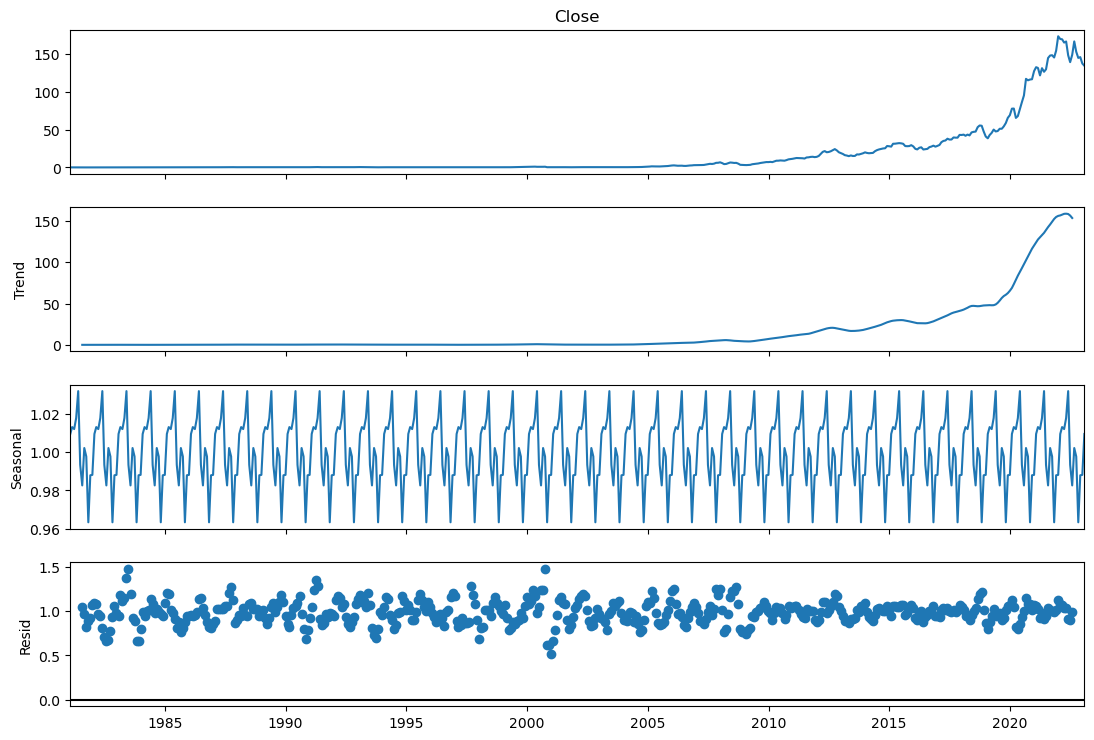

In [11]:
#1 Data loading and exploration
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose

df = pd.read_csv('Apple Stock Prices (1981 to 2023).csv',parse_dates=['Date'], index_col='Date')
print(df.head())

data_null = df.isnull().sum()
print("Null values in each column:\n", data_null)

df.info()
df.describe()


df.index = pd.to_datetime(df.index, dayfirst=True)

print("--- Vérification du nouvel Index ---")
print(type(df.index))  # Doit afficher <class 'pandas.core.indexes.datetimes.DatetimeIndex'>
print(f"Période : de {df.index.min()} à {df.index.max()}\n")

# 2. Vérification de la fréquence
print(f"Fréquence brute détectée : {df.index.freq}")

# Définir la fréquence sur les jours ouvrés (Business days)
df = df.asfreq('B')

# Note : Cela va créer des lignes vides pour les week-ends, on peut les propager 
# avec la dernière valeur connue (forward fill) pour boucher les trous économiques
df = df.ffill()
print(f"Nouvelle fréquence après ajustement : {df.index.freq}")

# Regrouper les données par mois (Moyenne mensuelle)
df_mensuel = df['Close'].resample('ME').mean()

# Décomposition de la tendance sur les données mensuelles (période de 12 mois)
decomposition = seasonal_decompose(df_mensuel, model='multiplicative', period=12)

# Affichage des tendances
fig = decomposition.plot()
fig.set_size_inches(12, 8)
plt.show()

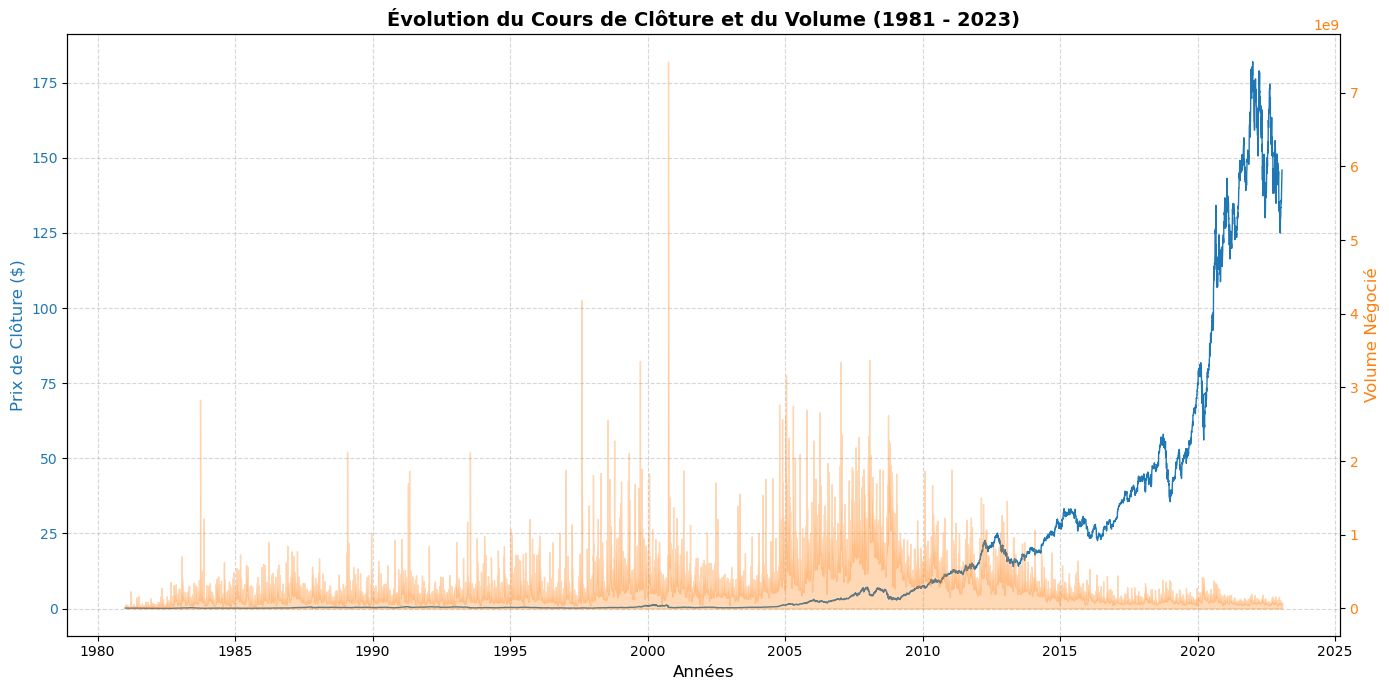

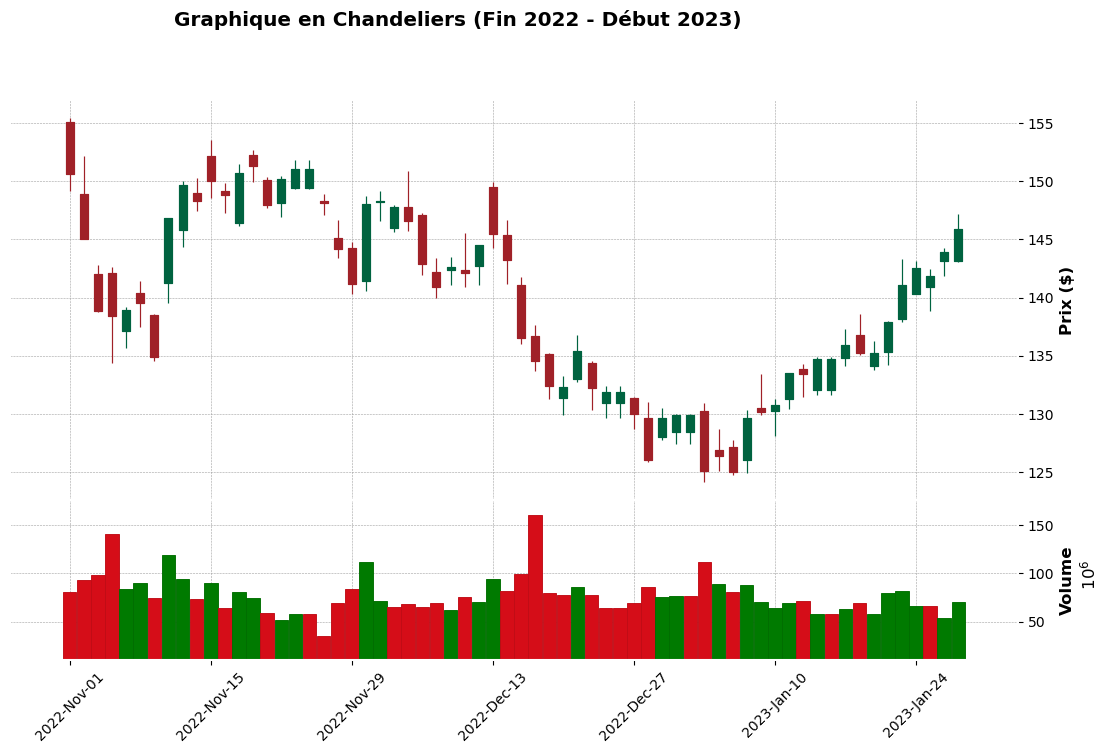

In [13]:
df.index = pd.to_datetime(df.index)

fig, ax1 = plt.subplots(figsize=(14, 7))

color = 'tab:blue'
ax1.set_xlabel('Années', fontsize=12)
ax1.set_ylabel('Prix de Clôture ($)', color=color, fontsize=12)
ax1.plot(df.index, df['Close'], color=color, linewidth=1)
ax1.tick_params(axis='y', labelcolor=color)
ax1.grid(True, linestyle='--', alpha=0.5)

ax2 = ax1.twinx()  
color = 'tab:orange'
ax2.set_ylabel('Volume Négocié', color=color, fontsize=12)
ax2.fill_between(df.index, df['Volume'], color=color, alpha=0.3)
ax2.tick_params(axis='y', labelcolor=color)

plt.title('Évolution du Cours de Clôture et du Volume (1981 - 2023)', fontsize=14, fontweight='bold')
fig.tight_layout()
plt.show()


#Graphique en chandeliers pour les prix élevés et bas
import mplfinance as mpf

df_zoom = df.loc['2022-11-01':'2023-01-27']

mpf.plot(df_zoom, 
         type='candle',        
         style='charles',      
         title='Graphique en Chandeliers (Fin 2022 - Début 2023)',
         ylabel='Prix ($)',
         volume=True,          
         ylabel_lower='Volume',
         figsize=(14, 8))

               Open          High           Low         Close        Volume
count  10976.000000  10976.000000  10976.000000  10976.000000  1.097600e+04
mean      16.719545     16.909668     16.531710     16.728001  3.254648e+08
std       35.473877     35.904915     35.055978     35.498457  3.361978e+08
min        0.049665      0.049665      0.049107      0.049107  0.000000e+00
25%        0.289063      0.297991      0.283482      0.290179  1.200416e+08
50%        0.490892      0.497768      0.482143      0.488839  2.128770e+08
75%       16.370982     16.504464     16.210090     16.338304  4.045643e+08
max      182.630005    182.940002    179.119995    182.009995  7.421641e+09


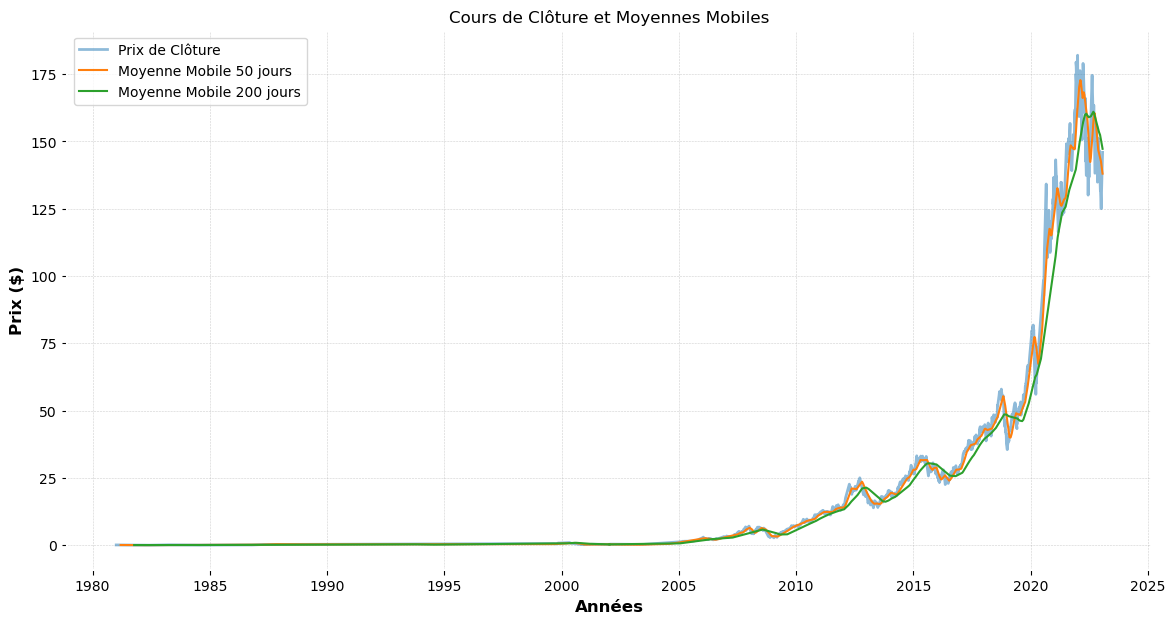

In [ ]:
#Analyse statistique
#les statistiques récapitulatives (moyenne, médiane, écart type) pour les colonnes clés
df.index = pd.to_datetime(df.index)

print(df[['Open', 'High', 'Low', 'Close', 'Volume']].describe())

df['MA_50'] = df['Close'].rolling(window=50).mean()
df['MA_200'] = df['Close'].rolling(window=200).mean()

plt.figure(figsize=(14, 7))
plt.plot(df.index, df['Close'], label='Prix de Clôture', alpha=0.5)
plt.plot(df.index, df['MA_50'], label='Moyenne Mobile 50 jours', linewidth=1.5)
plt.plot(df.index, df['MA_200'], label='Moyenne Mobile 200 jours', linewidth=1.5)
plt.title('Cours de Clôture et Moyennes Mobiles')
plt.xlabel('Années')
plt.ylabel('Prix ($)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()



In [18]:
from scipy import stats

prix_2021 = df.loc['2021', 'Close']
prix_2022 = df.loc['2022', 'Close']

t_stat, p_val = stats.ttest_ind(prix_2021, prix_2022, equal_var=False)

print(f"Moyenne 2021 : {prix_2021.mean():.2f}")
print(f"Moyenne 2022 : {prix_2022.mean():.2f}")
print(f"Statistique t : {t_stat:.4f}")
print(f"p-value : {p_val:.4e}")

Moyenne 2021 : 141.01
Moyenne 2022 : 154.72
Statistique t : -11.2041
p-value : 3.2763e-26


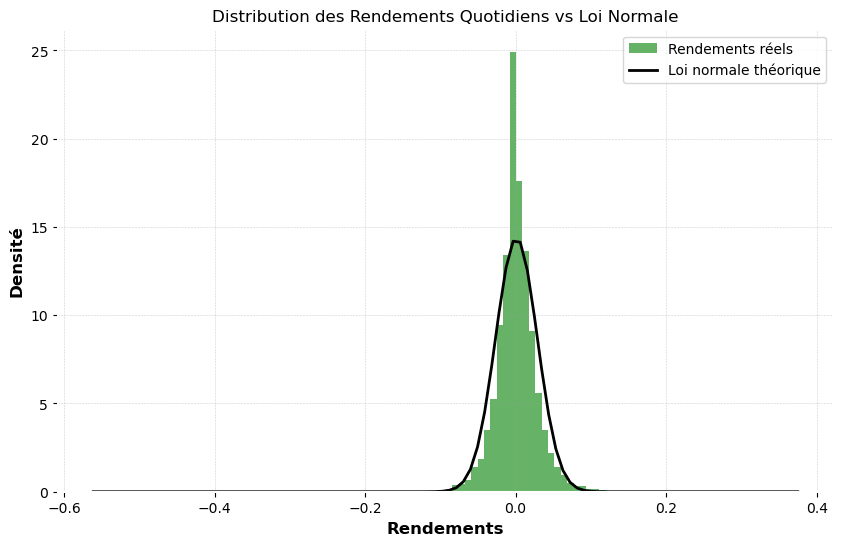

Statistique de test : 2859.6959
p-value du test de normalité : 0.0000e+00


In [19]:


df['Rendements'] = df['Close'].pct_change()
df_clean = df['Rendements'].dropna()

plt.figure(figsize=(10, 6))
plt.hist(df_clean, bins=100, density=True, alpha=0.6, color='g', label='Rendements réels')

mu, std = df_clean.mean(), df_clean.std()
xmin, xmax = plt.xlim()
x = np.linspace(xmin, xmax, 100)
p = stats.norm.pdf(x, mu, std)

plt.plot(x, p, 'k', linewidth=2, label='Loi normale théorique')
plt.title('Distribution des Rendements Quotidiens vs Loi Normale')
plt.xlabel('Rendements')
plt.ylabel('Densité')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

stat_norm, p_val_norm = stats.normaltest(df_clean)
print(f"Statistique de test : {stat_norm:.4f}")
print(f"p-value du test de normalité : {p_val_norm:.4e}")